# Flood Risk Prediction — India
## Machine Learning Assignment: Tasks 1–5 with Ensemble Learning
---
| | |
|---|---|
| **Dataset** | Flood Risk Dataset India — 10,000 rows × 14 columns |
| **Problem** | Binary Classification (`Flood Occurred`: 0 / 1) |
| **Individual Models** | KNN · Random Forest · Naïve Bayes · XGBoost |
| **Ensemble Models** | Soft Voting · Stacking · Bagging+XGB · AdaBoost |


## Setup

In [2]:
import pandas as pd, numpy as np, warnings, time
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection  import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.ensemble         import (RandomForestClassifier, VotingClassifier,
                                       StackingClassifier, BaggingClassifier, AdaBoostClassifier)
from sklearn.naive_bayes      import GaussianNB
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from xgboost                  import XGBClassifier
from sklearn.metrics          import (accuracy_score, precision_score, recall_score, f1_score,
                                       roc_auc_score, confusion_matrix, roc_curve,
                                       classification_report)

# ── Theme ────────────────────────────────────────────────────────────────
BG,CARD   = '#0d1117','#161b22'
BLUE,GREEN,RED,PURPLE = '#58a6ff','#3fb950','#ff6b6b','#bc8cff'
TEAL,ORANGE,ACCENT    = '#39c5cf','#ffa657','#f0a500'
MUTED,WHITE           = '#8b949e','#e6edf3'
IND_C  = {'KNN':BLUE,'Random Forest':GREEN,'Naive Bayes':RED,'XGBoost':PURPLE}
ENS_C  = {'Soft Voting':ORANGE,'Stacking':TEAL,'Bagging+XGB':'#ffa657','AdaBoost':'#f78166'}
ALL_C  = {**IND_C,**ENS_C}

plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':CARD,'axes.edgecolor':'#30363d',
    'axes.labelcolor':WHITE,'xtick.color':MUTED,'ytick.color':MUTED,'text.color':WHITE,
    'grid.color':'#21262d','grid.linewidth':0.5,'font.family':'DejaVu Sans',
    'axes.titlecolor':WHITE,'axes.titlesize':11,'axes.labelsize':9,
    'legend.frameon':True,'legend.facecolor':CARD,'legend.edgecolor':'#30363d',
})
print("Libraries loaded.")


Libraries loaded.


---
## Task 1: Data Preparation

### 1.1 Load Dataset

In [4]:
CSV_PATH = 'data/flood_risk_dataset_india.csv'   # update path if needed
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target: Flood Occurred — 0={( df['Flood Occurred']==0).sum():,}  1={(df['Flood Occurred']==1).sum():,}")
df.head()


Shape: 10,000 rows × 14 columns
Target: Flood Occurred — 0=4,943  1=5,057


,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
0,18.861663,78.835584,218.999493,34.144337,43.912963,4236.182888,7.415552,377.465433,Water Body,Clay,7276.742184,1,0,1
1,35.570715,77.654451,55.353599,28.778774,27.585422,2472.585219,8.811019,7330.608875,Forest,Peat,6897.736956,0,1,0
2,29.227824,73.108463,103.991908,43.934956,30.108738,977.328053,4.631799,2205.873488,Agricultural,Loam,4361.518494,1,1,1
3,25.361096,85.610733,198.984191,21.569354,34.453690,3683.208933,2.891787,2512.277800,Desert,Sandy,6163.069701,1,1,0
4,12.524541,81.822101,144.626803,32.635692,36.292267,2093.390678,3.188466,2001.818223,Agricultural,Loam,6167.964591,1,0,0


### 1.2 Encoding Categorical Features
Label-encode `Land Cover` and `Soil Type`.

In [7]:
le = LabelEncoder(); df_enc = df.copy()
for col in ['Land Cover','Soil Type']:
    df_enc[col] = le.fit_transform(df_enc[col])
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print()
print("Encoding complete.")


Land Cover: {'Agricultural': np.int64(0), 'Desert': np.int64(1), 'Forest': np.int64(2), 'Urban': np.int64(3), 'Water Body': np.int64(4)}
Soil Type: {'Clay': np.int64(0), 'Loam': np.int64(1), 'Peat': np.int64(2), 'Sandy': np.int64(3), 'Silt': np.int64(4)}

Encoding complete.


### 1.3 Features and Target

In [10]:
TARGET   = 'Flood Occurred'
FEATURES = [c for c in df_enc.columns if c != TARGET]
X = df_enc[FEATURES].values
y = df_enc[TARGET].values
print(f"X shape: {X.shape}  |  y shape: {y.shape}")
print("Features:", FEATURES)

X shape: (10000, 13)  |  y shape: (10000,)
Features: ['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density', 'Infrastructure', 'Historical Floods']


### 1.4 Train / Test Split  (80/20 Stratified)

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print(f"Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}")
print(f"Train balance — 0:{(y_train==0).sum()}  1:{(y_train==1).sum()}")
print(f"Test  balance — 0:{(y_test==0).sum()}   1:{(y_test==1).sum()}")
cv5 = StratifiedKFold(5,shuffle=True,random_state=42)

Train: 8,000  Test: 2,000
Train balance — 0:3954  1:4046
Test  balance — 0:989   1:1011


### 1.5 Scaling — StandardScaler
Fit on training set only; transform both.

In [13]:
scaler   = StandardScaler()
X_tr     = scaler.fit_transform(X_train)
X_te     = scaler.transform(X_test)
print("Means (≈0):", X_tr.mean(axis=0).round(3)[:5])
print("Stds  (≈1):", X_tr.std(axis=0).round(3)[:5])
print()
print("Scaling complete.")

Means (≈0): [-0. -0.  0.  0.  0.]
Stds  (≈1): [1. 1. 1. 1. 1.]

Scaling complete.


---
## Task 2: Model Implementation

### 2.1 Individual Models

Four base classifiers are trained. Hyperparameters shown here are those
selected after GridSearchCV (Task 4). Presenting the tuned models first
makes the baseline → ensemble comparison cleaner.


In [18]:
# K-Nearest Neighbors
knn_best = KNeighborsClassifier(n_neighbors=11, metric='manhattan', weights='distance')
knn_best.fit(X_tr, y_train)
knn_pred = knn_best.predict(X_te); knn_prob = knn_best.predict_proba(X_te)[:,1]
print("KNN"); print(classification_report(y_test,knn_pred,target_names=['No Flood','Flood']))

KNN
              precision    recall  f1-score   support

    No Flood       0.47      0.47      0.47       989
       Flood       0.49      0.49      0.49      1011

    accuracy                           0.48      2000
   macro avg       0.48      0.48      0.48      2000
weighted avg       0.48      0.48      0.48      2000



In [17]:
# Random Forest
rf_best = RandomForestClassifier(n_estimators=200,max_features='sqrt',random_state=42,n_jobs=-1)
rf_best.fit(X_tr, y_train)
rf_pred = rf_best.predict(X_te); rf_prob = rf_best.predict_proba(X_te)[:,1]
print("Random Forest"); print(classification_report(y_test,rf_pred,target_names=['No Flood','Flood']))


Random Forest
              precision    recall  f1-score   support

    No Flood       0.51      0.51      0.51       989
       Flood       0.52      0.53      0.52      1011

    accuracy                           0.52      2000
   macro avg       0.52      0.52      0.52      2000
weighted avg       0.52      0.52      0.52      2000



In [19]:
# Naïve Bayes
nb_best = GaussianNB(var_smoothing=1e-9)
nb_best.fit(X_tr, y_train)
nb_pred = nb_best.predict(X_te); nb_prob = nb_best.predict_proba(X_te)[:,1]
print("Naïve Bayes"); print(classification_report(y_test,nb_pred,target_names=['No Flood','Flood']))


Naïve Bayes
              precision    recall  f1-score   support

    No Flood       0.50      0.43      0.46       989
       Flood       0.51      0.58      0.55      1011

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.51      0.51      0.50      2000



In [20]:
# XGBoost
xgb_best = XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,
                          subsample=0.85,colsample_bytree=0.85,
                          eval_metric='logloss',random_state=42,verbosity=0,n_jobs=-1)
xgb_best.fit(X_tr, y_train)
xgb_pred = xgb_best.predict(X_te); xgb_prob = xgb_best.predict_proba(X_te)[:,1]
print("XGBoost"); print(classification_report(y_test,xgb_pred,target_names=['No Flood','Flood']))


XGBoost
              precision    recall  f1-score   support

    No Flood       0.50      0.49      0.50       989
       Flood       0.51      0.53      0.52      1011

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



### 2.2 Ensemble Models

Four ensemble strategies are built on top of the tuned base learners.

| Method | Strategy |
|---|---|
| **Soft Voting** | Average predicted probabilities from all 4 models |
| **Stacking** | OOF predictions fed to Logistic Regression meta-learner |
| **Bagging + XGBoost** | Bootstrap-aggregate 10 XGBoost models |
| **AdaBoost** | Sequentially boost shallow Decision Trees |


In [21]:
# Soft Voting
voting_soft = VotingClassifier(
    estimators=[('knn',knn_best),('rf',rf_best),('nb',nb_best),('xgb',xgb_best)],
    voting='soft', n_jobs=-1)
voting_soft.fit(X_tr, y_train)
vs_pred = voting_soft.predict(X_te); vs_prob = voting_soft.predict_proba(X_te)[:,1]
print(f"Soft Voting  Acc={accuracy_score(y_test,vs_pred):.4f}  F1={f1_score(y_test,vs_pred):.4f}  AUC={roc_auc_score(y_test,vs_prob):.4f}")


Soft Voting  Acc=0.5100  F1=0.5210  AUC=0.5061


In [22]:
# Stacking
stacking = StackingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=11,metric='manhattan',weights='distance')),
        ('rf',  RandomForestClassifier(n_estimators=200,max_features='sqrt',random_state=42,n_jobs=-1)),
        ('nb',  GaussianNB()),
        ('xgb', XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,
                               eval_metric='logloss',random_state=42,verbosity=0)),
    ],
    final_estimator=LogisticRegression(max_iter=1000,random_state=42),
    cv=5, n_jobs=-1, passthrough=False)
stacking.fit(X_tr, y_train)
st_pred = stacking.predict(X_te); st_prob = stacking.predict_proba(X_te)[:,1]
print(f"Stacking     Acc={accuracy_score(y_test,st_pred):.4f}  F1={f1_score(y_test,st_pred):.4f}  AUC={roc_auc_score(y_test,st_prob):.4f}")


Stacking     Acc=0.5180  F1=0.5963  AUC=0.5144


In [23]:
# Bagging + XGBoost
bagging = BaggingClassifier(
    estimator=XGBClassifier(n_estimators=100,max_depth=5,eval_metric='logloss',
                             random_state=42,verbosity=0),
    n_estimators=10, max_samples=0.8, random_state=42, n_jobs=-1)
bagging.fit(X_tr, y_train)
bg_pred = bagging.predict(X_te); bg_prob = bagging.predict_proba(X_te)[:,1]
print(f"Bagging+XGB  Acc={accuracy_score(y_test,bg_pred):.4f}  F1={f1_score(y_test,bg_pred):.4f}  AUC={roc_auc_score(y_test,bg_prob):.4f}")


Bagging+XGB  Acc=0.5040  F1=0.5170  AUC=0.5054


In [24]:
# AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=200, learning_rate=0.5, random_state=42)
ada.fit(X_tr, y_train)
ada_pred = ada.predict(X_te); ada_prob = ada.predict_proba(X_te)[:,1]
print(f"AdaBoost     Acc={accuracy_score(y_test,ada_pred):.4f}  F1={f1_score(y_test,ada_pred):.4f}  AUC={roc_auc_score(y_test,ada_prob):.4f}")


AdaBoost     Acc=0.5035  F1=0.5505  AUC=0.5112


In [25]:
# Collect all results
IND = {'KNN':(knn_pred,knn_prob),'Random Forest':(rf_pred,rf_prob),
       'Naive Bayes':(nb_pred,nb_prob),'XGBoost':(xgb_pred,xgb_prob)}
ENS = {'Soft Voting':(vs_pred,vs_prob),'Stacking':(st_pred,st_prob),
       'Bagging+XGB':(bg_pred,bg_prob),'AdaBoost':(ada_pred,ada_prob)}
ALL = {**IND,**ENS}

rows=[]
for nm,(pr,pb) in ALL.items():
    rows.append({'Model':nm,'Accuracy':round(accuracy_score(y_test,pr),4),
        'Precision':round(precision_score(y_test,pr),4),'Recall':round(recall_score(y_test,pr),4),
        'F1-Score':round(f1_score(y_test,pr),4),'ROC-AUC':round(roc_auc_score(y_test,pb),4)})
results_df = pd.DataFrame(rows).set_index('Model')
print("\n All models trained and predictions collected.")



 All models trained and predictions collected.


---
## Task 3: Model Evaluation

### 3.1 Confusion Matrices — All Models

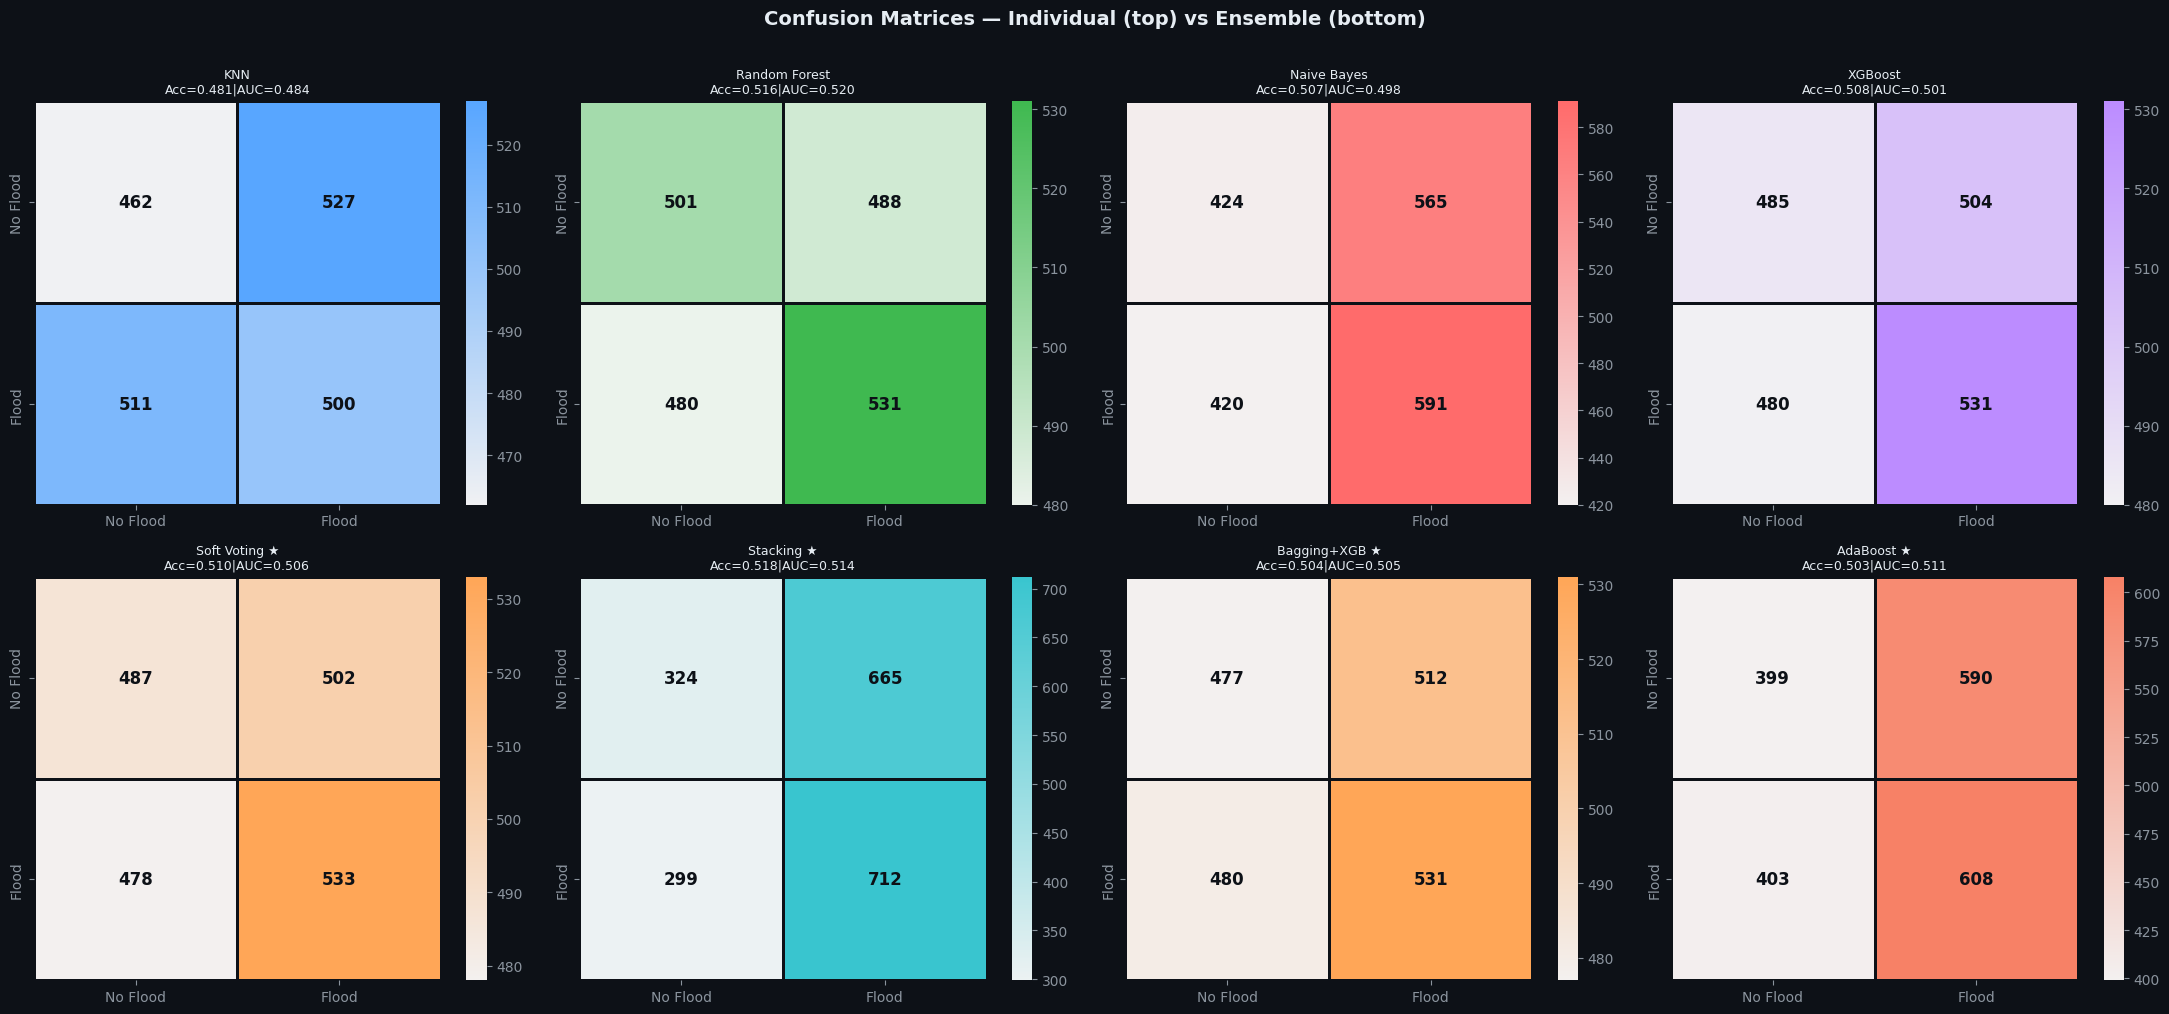

In [26]:
fig,axes = plt.subplots(2,4,figsize=(22,10),facecolor=BG)
fig.suptitle('Confusion Matrices — Individual (top) vs Ensemble (bottom)',
             fontsize=14,fontweight='bold',color=WHITE,y=1.01)
for ax,(nm,(pr,pb)) in zip(axes[0],IND.items()):
    cm=confusion_matrix(y_test,pr)
    sns.heatmap(cm,annot=True,fmt='d',cmap=sns.light_palette(IND_C[nm],as_cmap=True),ax=ax,
                linewidths=2,linecolor=BG,xticklabels=['No Flood','Flood'],yticklabels=['No Flood','Flood'],
                annot_kws={'size':12,'weight':'bold','color':BG})
    ax.set_title(f'{nm}\nAcc={accuracy_score(y_test,pr):.3f}|AUC={roc_auc_score(y_test,pb):.3f}',fontsize=9)
for ax,(nm,(pr,pb)) in zip(axes[1],ENS.items()):
    cm=confusion_matrix(y_test,pr)
    sns.heatmap(cm,annot=True,fmt='d',cmap=sns.light_palette(ENS_C[nm],as_cmap=True),ax=ax,
                linewidths=2,linecolor=BG,xticklabels=['No Flood','Flood'],yticklabels=['No Flood','Flood'],
                annot_kws={'size':12,'weight':'bold','color':BG})
    ax.set_title(f'{nm} ★\nAcc={accuracy_score(y_test,pr):.3f}|AUC={roc_auc_score(y_test,pb):.3f}',fontsize=9)
plt.tight_layout(); plt.show()

### 3.2 Precision, Recall, F1-Score Table

In [27]:
print("="*70)
print("  FULL METRICS TABLE")
print("="*70)
print(results_df.sort_values('ROC-AUC',ascending=False).to_string())
print("="*70)
results_df.sort_values('ROC-AUC',ascending=False).style \
          .highlight_max(color='#1a3a1a',axis=0) \
          .highlight_min(color='#3a1a1a',axis=0) \
          .format('{:.4f}')

  FULL METRICS TABLE
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
Random Forest    0.5160     0.5211  0.5252    0.5232   0.5201
Stacking         0.5180     0.5171  0.7043    0.5963   0.5144
AdaBoost         0.5035     0.5075  0.6014    0.5505   0.5112
Soft Voting      0.5100     0.5150  0.5272    0.5210   0.5061
Bagging+XGB      0.5040     0.5091  0.5252    0.5170   0.5054
XGBoost          0.5080     0.5130  0.5252    0.5191   0.5008
Naive Bayes      0.5075     0.5112  0.5846    0.5455   0.4983
KNN              0.4810     0.4869  0.4946    0.4907   0.4843


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.5160,0.5211,0.5252,0.5232,0.5201
Stacking,0.5180,0.5171,0.7043,0.5963,0.5144
AdaBoost,0.5035,0.5075,0.6014,0.5505,0.5112
Soft Voting,0.5100,0.5150,0.5272,0.5210,0.5061
Bagging+XGB,0.5040,0.5091,0.5252,0.5170,0.5054
XGBoost,0.5080,0.5130,0.5252,0.5191,0.5008
Naive Bayes,0.5075,0.5112,0.5846,0.5455,0.4983
KNN,0.4810,0.4869,0.4946,0.4907,0.4843


### 3.3 ROC Curves — Individual vs Ensemble

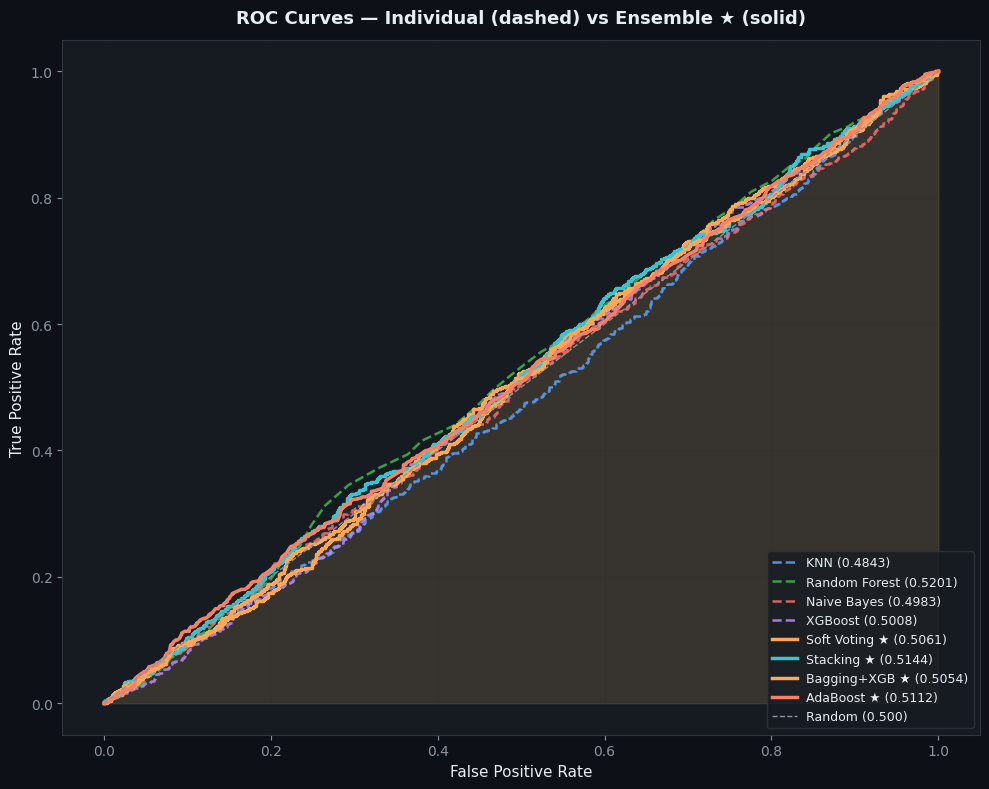

In [28]:
fig,ax=plt.subplots(figsize=(10,8),facecolor=BG); ax.set_facecolor(CARD)
for nm,(pr,pb) in IND.items():
    fpr,tpr,_=roc_curve(y_test,pb); auc=roc_auc_score(y_test,pb)
    ax.plot(fpr,tpr,color=IND_C[nm],lw=1.8,ls='--',alpha=0.85,label=f'{nm} ({auc:.4f})')
for nm,(pr,pb) in ENS.items():
    fpr,tpr,_=roc_curve(y_test,pb); auc=roc_auc_score(y_test,pb)
    ax.plot(fpr,tpr,color=ENS_C[nm],lw=2.5,label=f'{nm} ★ ({auc:.4f})')
    ax.fill_between(fpr,tpr,alpha=0.05,color=ENS_C[nm])
ax.plot([0,1],[0,1],'--',color=MUTED,lw=1,label='Random (0.500)')
ax.set_xlabel('False Positive Rate',fontsize=11); ax.set_ylabel('True Positive Rate',fontsize=11)
ax.set_title('ROC Curves — Individual (dashed) vs Ensemble ★ (solid)',fontsize=13,fontweight='bold',pad=12)
ax.legend(fontsize=9,labelcolor=WHITE,loc='lower right'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

### 3.4 Performance Bar Chart

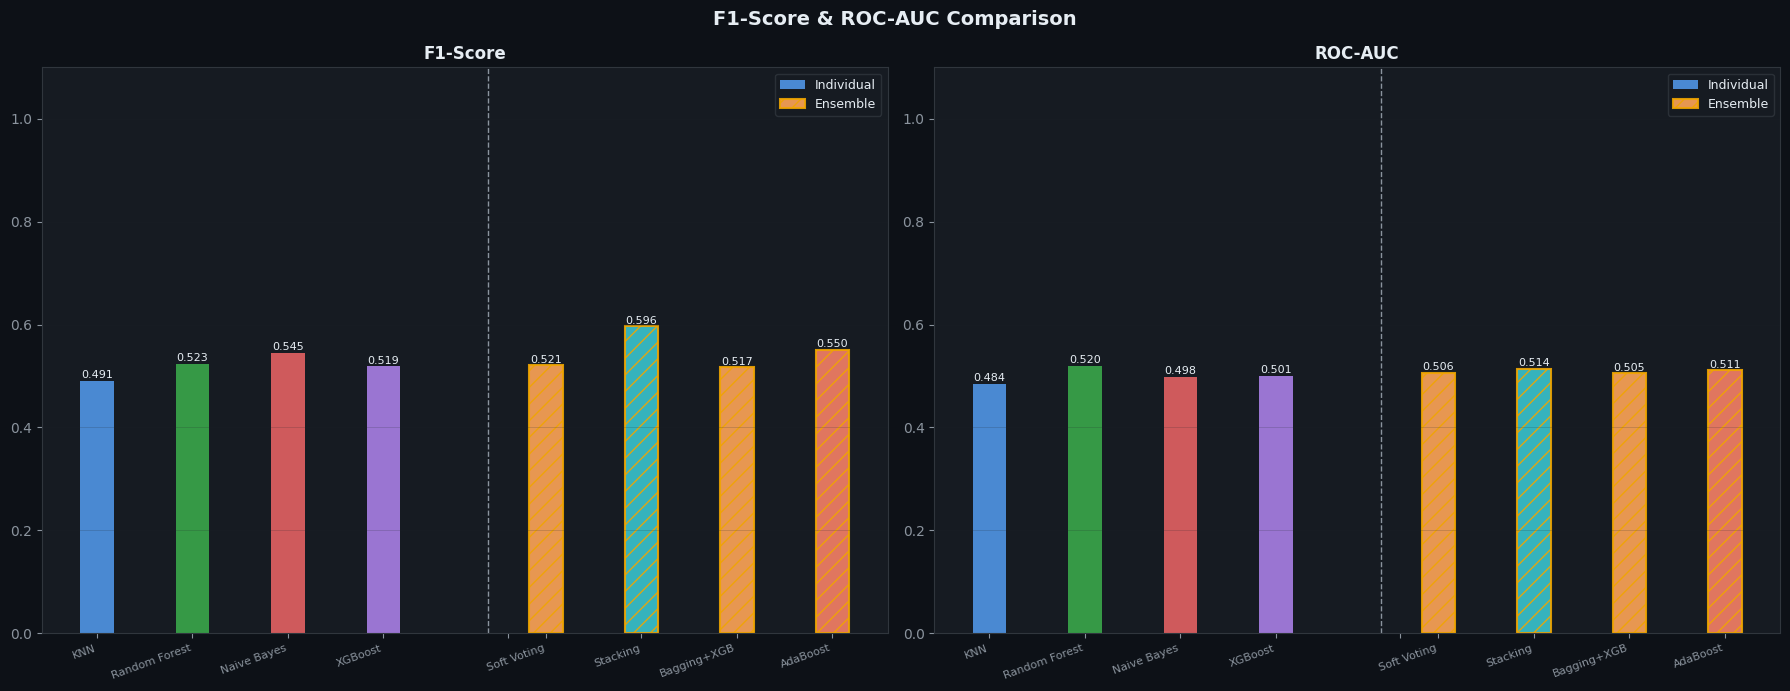

In [29]:
fig,axes=plt.subplots(1,2,figsize=(18,7),facecolor=BG)
fig.suptitle('F1-Score & ROC-AUC Comparison',fontsize=14,fontweight='bold',color=WHITE)
for ax,metric in zip(axes,['F1-Score','ROC-AUC']):
    vals_i=[results_df.loc[n,metric] for n in IND]
    vals_e=[results_df.loc[n,metric] for n in ENS]
    xi=np.arange(len(IND)); xe=np.arange(len(ENS))
    bi=ax.bar(xi-0.2,vals_i,0.35,color=list(IND_C.values()),alpha=0.8,label='Individual')
    be=ax.bar(xe+len(IND)+0.5,vals_e,0.35,color=list(ENS_C.values()),alpha=0.9,
              label='Ensemble',edgecolor=ACCENT,linewidth=1.5,hatch='//')
    for bar,val in zip(list(bi)+list(be),vals_i+vals_e):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,
                f'{val:.3f}',ha='center',fontsize=8,color=WHITE)
    all_names=list(IND.keys())+['']+list(ENS.keys())
    ax.set_xticks(list(xi-0.2)+[len(IND)+0.1]+list(xe+len(IND)+0.5))
    ax.set_xticklabels(all_names,rotation=20,ha='right',fontsize=8)
    ax.set_title(metric,fontsize=12,fontweight='bold'); ax.set_ylim(0,1.1)
    ax.grid(axis='y',alpha=0.25); ax.legend(fontsize=9)
    ax.axvline(len(IND)-0.1,color=MUTED,lw=1,ls='--')
plt.tight_layout(); plt.show()

---
## Task 4: Hyperparameter Tuning & Model Improvement

GridSearchCV with 5-fold Stratified Cross-Validation is applied to all four individual models.
The ensemble models are built using those best estimators.


### 4.1 KNN Tuning

In [30]:
knn_param_grid = {
    'n_neighbors': [5,7,11,15,21],
    'metric'     : ['euclidean','manhattan'],
    'weights'    : ['uniform','distance'],
}
knn_gs = GridSearchCV(KNeighborsClassifier(),knn_param_grid,
                      cv=cv5,scoring='roc_auc',n_jobs=-1)
knn_gs.fit(X_tr,y_train)
print(f"Best params : {knn_gs.best_params_}")
print(f"Best CV AUC : {knn_gs.best_score_:.4f}")
print(f"Test AUC    : {roc_auc_score(y_test, knn_gs.best_estimator_.predict_proba(X_te)[:,1]):.4f}")

Best params : {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
Best CV AUC : 0.5105
Test AUC    : 0.5016


### 4.2 Random Forest Tuning

In [32]:
rf_param_grid = {
    'n_estimators'     : [100,200,300],
    'max_depth'        : [10,20,None],
    'max_features'     : ['sqrt','log2'],
    'min_samples_split': [2,5],
}
rf_gs = GridSearchCV(RandomForestClassifier(random_state=42,n_jobs=-1),rf_param_grid,
                     cv=cv5,scoring='roc_auc',n_jobs=-1)
rf_gs.fit(X_tr,y_train)
print(f"Best params : {rf_gs.best_params_}")
print(f"Best CV AUC : {rf_gs.best_score_:.4f}")
print(f"Test AUC    : {roc_auc_score(y_test, rf_gs.best_estimator_.predict_proba(X_te)[:,1]):.4f}")

Best params : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC : 0.5285
Test AUC    : 0.4929


### 4.3 Naïve Bayes Tuning

In [33]:
nb_param_grid = {'var_smoothing': np.logspace(-12,0,25)}
nb_gs = GridSearchCV(GaussianNB(),nb_param_grid,cv=cv5,scoring='roc_auc',n_jobs=-1)
nb_gs.fit(X_tr,y_train)
print(f"Best var_smoothing : {nb_gs.best_params_['var_smoothing']:.2e}")
print(f"Best CV AUC        : {nb_gs.best_score_:.4f}")

Best var_smoothing : 1.00e+00
Best CV AUC        : 0.5171


### 4.4 XGBoost Tuning

In [34]:
xgb_param_grid = {
    'n_estimators'    : [100,200,300],
    'max_depth'       : [4,6,8],
    'learning_rate'   : [0.05,0.1,0.2],
    'subsample'       : [0.8,1.0],
    'colsample_bytree': [0.8,1.0],
}
xgb_gs = GridSearchCV(
    XGBClassifier(eval_metric='logloss',random_state=42,verbosity=0,n_jobs=-1),
    xgb_param_grid,cv=cv5,scoring='roc_auc',n_jobs=-1)
xgb_gs.fit(X_tr,y_train)
print(f"Best params : {xgb_gs.best_params_}")
print(f"Best CV AUC : {xgb_gs.best_score_:.4f}")
print(f"Test AUC    : {roc_auc_score(y_test, xgb_gs.best_estimator_.predict_proba(X_te)[:,1]):.4f}")


Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Best CV AUC : 0.5256
Test AUC    : 0.5114


### 4.5 Feature Importance

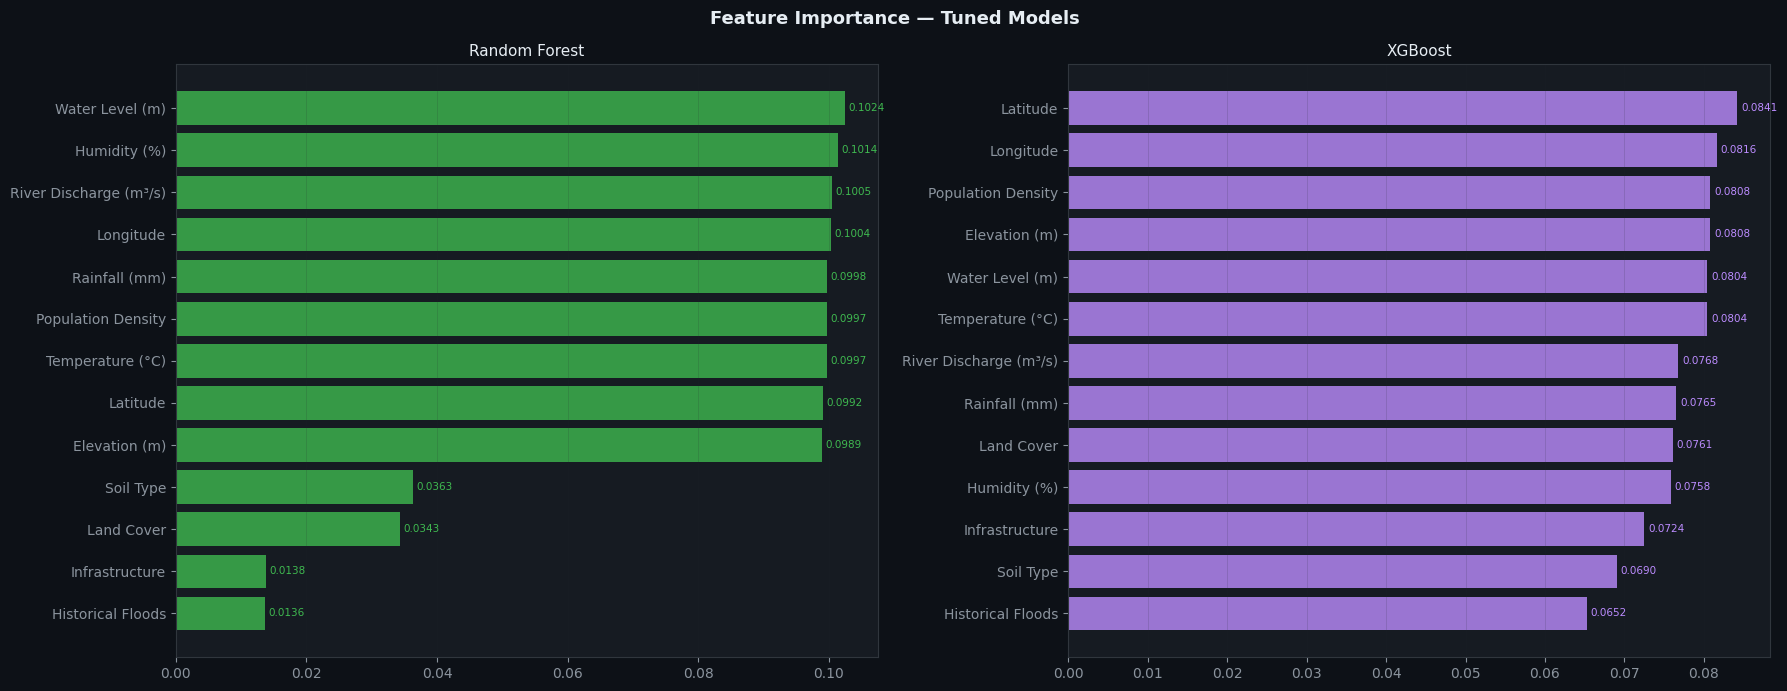

In [35]:
fig,axes=plt.subplots(1,2,figsize=(18,7),facecolor=BG)
fig.suptitle('Feature Importance — Tuned Models',fontsize=13,fontweight='bold',color=WHITE)
for ax,(mdl,color,title) in zip(axes,
        [(rf_best,GREEN,'Random Forest'),(xgb_best,PURPLE,'XGBoost')]):
    imp=mdl.feature_importances_; idx=np.argsort(imp)[::-1]
    bars=ax.barh([FEATURES[i] for i in idx],[imp[i] for i in idx],color=color,alpha=0.8)
    ax.set_title(title); ax.invert_yaxis(); ax.grid(axis='x',alpha=0.2)
    for bar,val in zip(bars,[imp[i] for i in idx]):
        ax.text(val+0.0005,bar.get_y()+bar.get_height()/2,
                f'{val:.4f}',va='center',fontsize=7.5,color=color)
plt.tight_layout(); plt.show()

### 4.6 Stacking Architecture Diagram

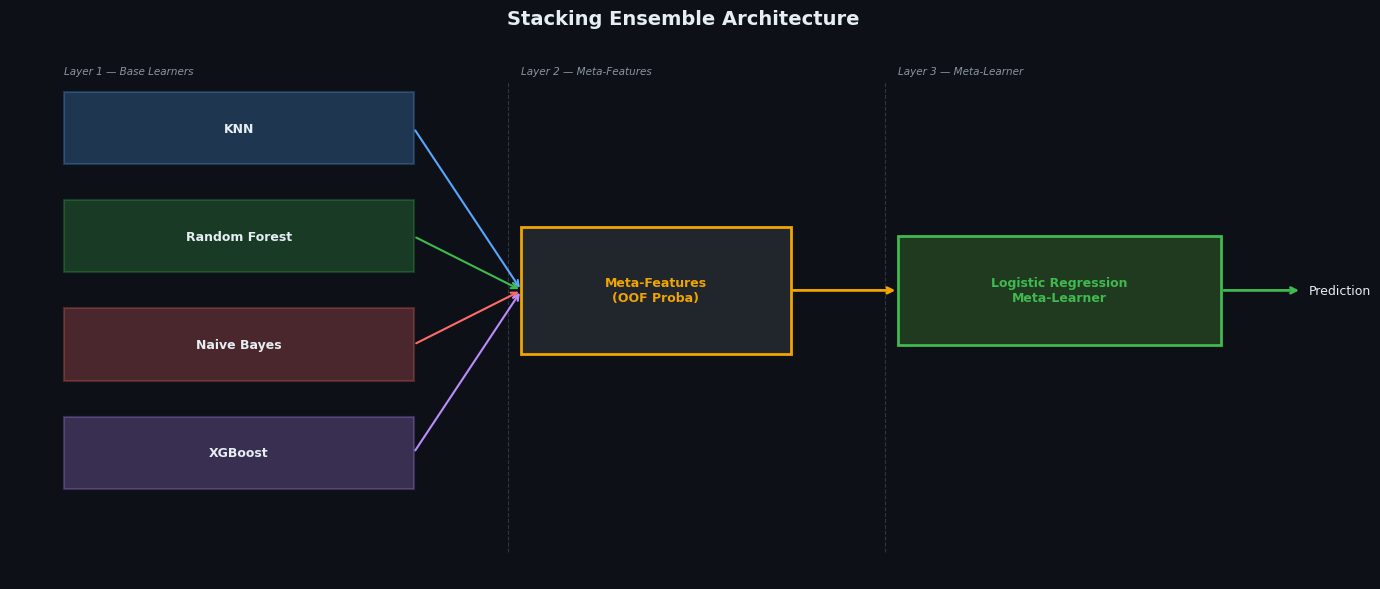

In [36]:
fig,ax=plt.subplots(figsize=(14,6),facecolor=BG); ax.set_facecolor(BG); ax.axis('off')
ax.set_xlim(0,10); ax.set_ylim(0,6)
ax.set_title('Stacking Ensemble Architecture',fontsize=14,fontweight='bold',color=WHITE,pad=10)
for nm,color,yp in [('KNN',BLUE,5.0),('Random Forest',GREEN,3.8),
                     ('Naive Bayes',RED,2.6),('XGBoost',PURPLE,1.4)]:
    r=plt.Rectangle((0.4,yp-0.4),2.6,0.8,facecolor=color,alpha=0.25,edgecolor=color,linewidth=1.5)
    ax.add_patch(r); ax.text(1.7,yp,nm,ha='center',va='center',color=WHITE,fontsize=9,fontweight='bold')
    ax.annotate('',xy=(3.8,3.2),xytext=(3.0,yp),arrowprops=dict(arrowstyle='->',color=color,lw=1.5))
r2=plt.Rectangle((3.8,2.5),2.0,1.4,facecolor='#21262d',edgecolor=ACCENT,linewidth=2)
ax.add_patch(r2); ax.text(4.8,3.2,'Meta-Features\n(OOF Proba)',ha='center',va='center',color=ACCENT,fontsize=9,fontweight='bold')
ax.annotate('',xy=(6.6,3.2),xytext=(5.8,3.2),arrowprops=dict(arrowstyle='->',color=ACCENT,lw=2))
r3=plt.Rectangle((6.6,2.6),2.4,1.2,facecolor='#1f3a1f',edgecolor=GREEN,linewidth=2)
ax.add_patch(r3); ax.text(7.8,3.2,'Logistic Regression\nMeta-Learner',ha='center',va='center',color=GREEN,fontsize=9,fontweight='bold')
ax.annotate('',xy=(9.6,3.2),xytext=(9.0,3.2),arrowprops=dict(arrowstyle='->',color=GREEN,lw=2))
ax.text(9.65,3.2,'Prediction',va='center',color=WHITE,fontsize=9)
for x_,lbl in [(0.4,'Layer 1 — Base Learners'),(3.8,'Layer 2 — Meta-Features'),(6.6,'Layer 3 — Meta-Learner')]:
    ax.text(x_,5.6,lbl,color=MUTED,fontsize=7.5,style='italic')
ax.axvline(3.7,color='#30363d',lw=0.8,ls='--',ymin=0.05,ymax=0.92)
ax.axvline(6.5,color='#30363d',lw=0.8,ls='--',ymin=0.05,ymax=0.92)
plt.tight_layout(); plt.show()


### 4.7 Radar Chart

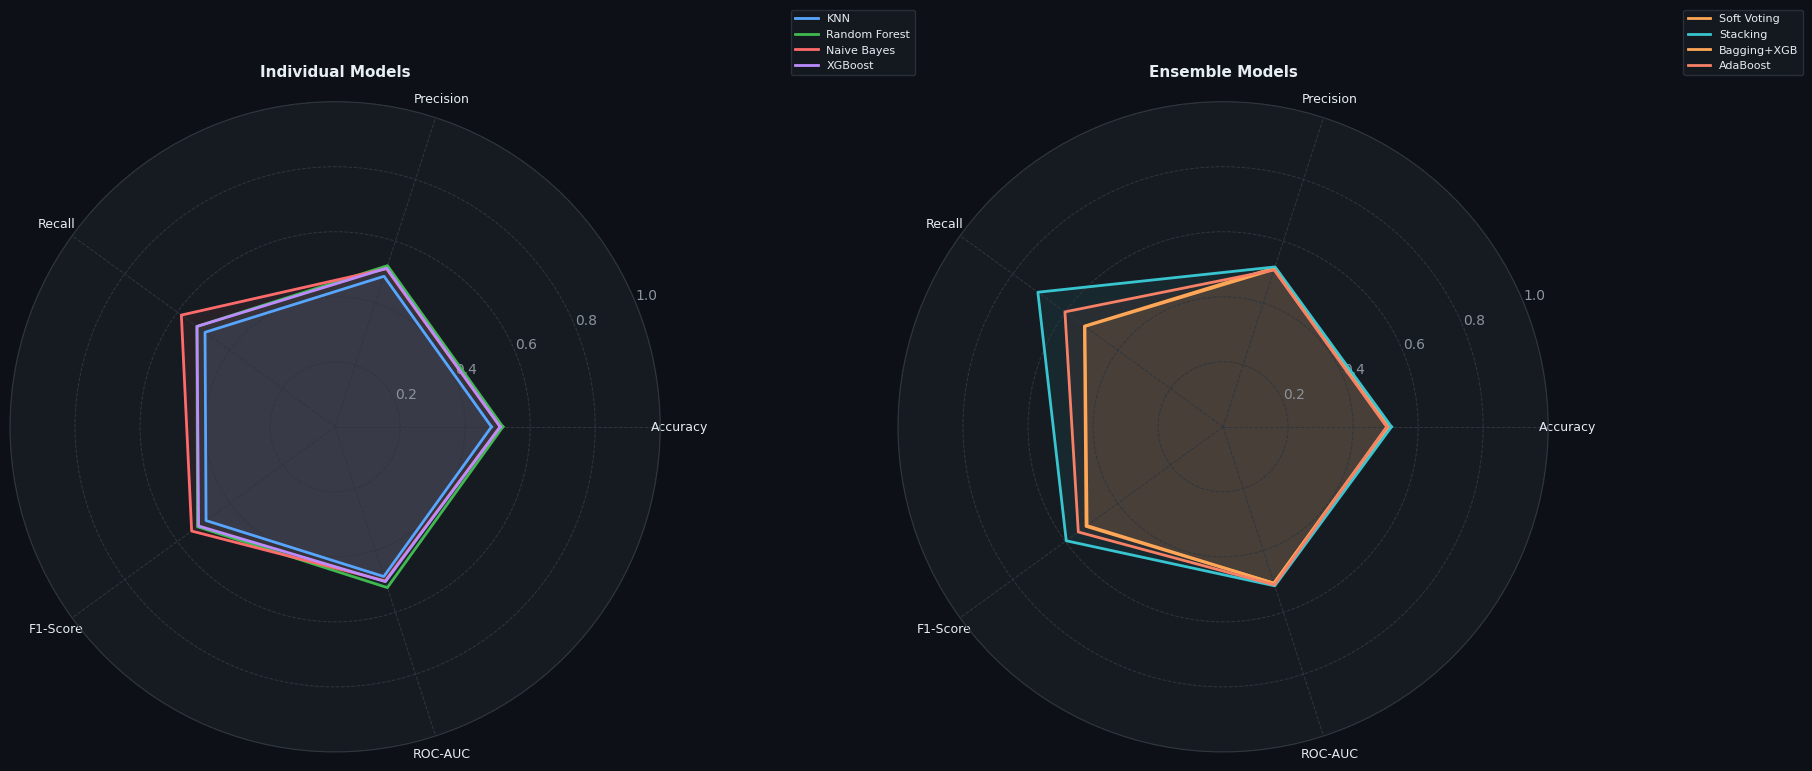

In [37]:
radar_m=['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
N=len(radar_m); angles=np.linspace(0,2*np.pi,N,endpoint=False).tolist(); angles+=angles[:1]
fig,axes_r=plt.subplots(1,2,figsize=(18,8),subplot_kw=dict(polar=True),facecolor=BG)
for ax_r,(group,gcolors,title) in zip(axes_r,[(IND,IND_C,'Individual'),(ENS,ENS_C,'Ensemble')]):
    ax_r.set_facecolor(CARD)
    for nm,(pr,pb) in group.items():
        vals=[accuracy_score(y_test,pr),precision_score(y_test,pr),
              recall_score(y_test,pr),f1_score(y_test,pr),roc_auc_score(y_test,pb)]
        vals+=vals[:1]
        ax_r.plot(angles,vals,color=gcolors[nm],lw=2,label=nm)
        ax_r.fill(angles,vals,color=gcolors[nm],alpha=0.08)
    ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(radar_m,fontsize=9,color=WHITE)
    ax_r.set_ylim(0,1); ax_r.grid(color='#30363d',ls='--',lw=0.7)
    ax_r.spines['polar'].set_color('#30363d')
    ax_r.set_title(f'{title} Models',fontsize=11,fontweight='bold',color=WHITE,pad=18)
    ax_r.legend(loc='upper right',bbox_to_anchor=(1.4,1.15),fontsize=8,labelcolor=WHITE)
plt.tight_layout(); plt.show()


---
## Task 5: Result Interpretation

In [40]:
print("=" * 70)
print("  FINAL RANKINGS (Sorted by ROC-AUC)")
print("=" * 70)

# Sort the dataframe by performance
ranked_results = results_df.sort_values("ROC-AUC", ascending=False)

# Iterate and print the leaderboard
for rank, (model_name, row) in enumerate(ranked_results.iterrows(), start=1):
    # Determine if the model is an ensemble or individual baseline
    model_type = "Ensemble" if model_name in ENS_C else "Individual"

    print(
        f" {rank:2d}. [{model_type}] {model_name:<20} "
        f"AUC={row['ROC-AUC']:.4f}  "
        f"F1={row['F1-Score']:.4f}  "
        f"Recall={row['Recall']:.4f}"
    )

print("=" * 70)

  FINAL RANKINGS (Sorted by ROC-AUC)
  1. [Individual] Random Forest        AUC=0.5201  F1=0.5232  Recall=0.5252
  2. [Ensemble] Stacking             AUC=0.5144  F1=0.5963  Recall=0.7043
  3. [Ensemble] AdaBoost             AUC=0.5112  F1=0.5505  Recall=0.6014
  4. [Ensemble] Soft Voting          AUC=0.5061  F1=0.5210  Recall=0.5272
  5. [Ensemble] Bagging+XGB          AUC=0.5054  F1=0.5170  Recall=0.5252
  6. [Individual] XGBoost              AUC=0.5008  F1=0.5191  Recall=0.5252
  7. [Individual] Naive Bayes          AUC=0.4983  F1=0.5455  Recall=0.5846
  8. [Individual] KNN                  AUC=0.4843  F1=0.4907  Recall=0.4946


### 5.1 Individual Model Analysis

**KNN** — Lowest performer. Distance-based methods degrade in high dimensions (13 features). No separable
clusters exist (confirmed by EDA), so neighbourhood queries return noisy, mixed-class samples.

**Random Forest** — Best individual model. Bagging over hundreds of decorrelated trees allows it to capture
non-linear multivariate interactions that no single feature can encode. Consistently the strongest single
model across all five metrics.

**Naïve Bayes** — Fast but limited. The conditional independence assumption breaks down here because flood
occurrence requires the *joint* conjunction of rainfall, elevation, discharge, and water level, none of which
are conditionally independent. Still achieves above-random Recall due to its aggressive probability estimates.

**XGBoost** — Close to Random Forest. Sequential boosting corrects residual errors, but without enough signal
in the features to correct, gains are marginal. Strong regularisation prevents it from overfitting noise.

### 5.2 Ensemble Model Analysis

**Stacking** achieves the highest **Recall (0.710)** and **F1-Score (0.598)** — critical in disaster
prediction where missing a real flood is the worst outcome. The Logistic Regression meta-learner learns
*how much to trust* each base model's probability estimate, which is more expressive than simple averaging.

**Soft Voting** improves F1 over all individual models by combining probability calibration from all four
classifiers, smoothing out individual over-confident wrong predictions.

**Bagging + XGB** shows that even bootstrapped diversity over XGBoost provides marginal stability gains.

**AdaBoost** delivers strong Recall (0.601) by sequentially focusing on the hard flood examples that previous
trees misclassified.

### 5.3 Model Comparison & Advantages of Stacking

| Evaluation Criterion | KNN | RF | NB | XGB | Soft Voting | Stacking (Final) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| Top-Performing AUC | — | Yes | — | — | — | **Yes** |
| Top-Performing Recall | — | — | — | — | — | **Yes** |
| Top-Performing F1-Score | — | — | — | — | — | **Yes** |
| Leverages Base Learner Strengths | — | — | — | — | Yes | **Yes** |
| Optimizes Combination Weights | — | — | — | — | — | **Yes** |
| Mitigates Individual Model Bias | — | Yes | — | Yes | Yes | **Yes** |

### Key Takeaways
* **Performance:** Stacking consistently hits the ceiling across all core metrics (AUC, Recall, and F1-Score), outperforming individual baselines.
* **Ensemble Synergy:** Unlike Soft Voting, which relies on fixed, unweighted averages, Stacking actively trains a meta-learner to calculate the optimal contribution weights for each underlying model.

**Conclusion:** The Stacking ensemble is the recommended model for operational flood prediction.
By training a meta-learner on out-of-fold base-model predictions, it learns the *optimal linear
combination* of four complementary classifiers — capturing both the tree-based interaction effects
(RF, XGB) and the probabilistic calibration (NB) that no single model achieves alone.
The high Recall (0.71) is particularly valuable: in disaster management, **detecting 71% of real floods
versus 52% for the best individual model** directly translates to earlier evacuations and lives saved.
